# Japan Birth analysis(1899-2023)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
os.makedirs('../plots', exist_ok=True)
# ── Dark Theme ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d0d1a',
    'axes.facecolor':   '#0d0d1a',
    'axes.edgecolor':   '#2a2a40',
    'axes.titlecolor':  '#ffffff',
    'axes.labelcolor':  '#d0d0e0',
    'xtick.color':      '#a0a0b8',
    'ytick.color':      '#a0a0b8',
    'text.color':       '#d0d0e0',
    'grid.color':       '#1a1a2e',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
    'legend.fontsize':  9,
    'legend.framealpha': 0.15,
    'legend.edgecolor': '#333355',
})

# ── Colour Palette ────────────────────────────────────────────
C = dict(
    red    = '#e94560',
    teal   = '#00b4d8',
    gold   = '#f5a623',
    purple = '#7b2ff7',
    green  = '#06d6a0',
    pink   = '#f72585',
    blue   = '#4361ee',
    orange = '#ff9f1c',
    white  = '#e8e8f0',
)

In [2]:
df = pd.read_csv("../data/japan_birth_statistics_1899_2023.csv")
df = df.sort_values("year").reset_index(drop=True)  #oldest year first, newest last , rest_index fixes the index number


In [3]:
df.shape

(122, 7)

In [4]:
df.columns

Index(['year', 'total_births', 'male_births', 'female_births',
       'crude_birth_rate', 'sex_ratio_at_birth', 'total_fertility_rate'],
      dtype='object')

In [5]:
df.head(10) # Top 10 values

,year,total_births,male_births,female_births,crude_birth_rate,sex_ratio_at_birth,total_fertility_rate
0,1899,1386981,713442,673539,32.0,105.9,NaN
1,1900,1420534,727916,692618,32.4,105.1,NaN
2,1901,1501591,769494,732097,33.9,105.1,NaN
3,1902,1510835,773296,737539,33.6,104.8,NaN
4,1903,1489816,763806,726010,32.7,105.2,NaN
5,1904,1440371,738230,702141,31.2,105.1,NaN
6,1905,1452770,735948,716822,31.2,102.7,NaN
7,1906,1394295,726155,668140,29.6,108.7,NaN
8,1907,1614472,818114,796358,34.0,102.7,NaN
9,1908,1662815,850209,812606,34.7,104.6,NaN


In [6]:
df.dtypes #Checking the column name and datatypes

year                      int64
total_births              int64
male_births               int64
female_births             int64
crude_birth_rate        float64
sex_ratio_at_birth      float64
total_fertility_rate    float64
dtype: object

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,122.0,1.961393e+03,36.585812,1899.0,1929.250,1962.50,1992.750,2023.00
total_births,122.0,1.619319e+06,439286.360806,727288.0,1212138.000,1656495.00,1985485.500,2696638.00
male_births,122.0,8.304865e+05,224926.109670,372603.0,623344.750,849471.00,1014098.250,1380008.00
female_births,122.0,7.888323e+05,214416.989182,354685.0,588793.250,805848.00,967350.000,1316630.00
crude_birth_rate,122.0,2.082459e+01,10.534323,6.0,9.825,18.60,32.375,36.20
sex_ratio_at_birth,122.0,1.053107e+02,0.858387,102.7,104.900,105.30,105.800,108.70
total_fertility_rate,77.0,1.860779e+00,0.696069,1.2,1.390,1.72,2.050,4.54


In [8]:
df.describe(include="int64")

,year,total_births,male_births,female_births
count,122.000000,1.220000e+02,1.220000e+02,1.220000e+02
mean,1961.393443,1.619319e+06,8.304865e+05,7.888323e+05
std,36.585812,4.392864e+05,2.249261e+05,2.144170e+05
min,1899.000000,7.272880e+05,3.726030e+05,3.546850e+05
25%,1929.250000,1.212138e+06,6.233448e+05,5.887932e+05
50%,1962.500000,1.656495e+06,8.494710e+05,8.058480e+05
75%,1992.750000,1.985486e+06,1.014098e+06,9.673500e+05
max,2023.000000,2.696638e+06,1.380008e+06,1.316630e+06


# Data Cleaning

In [9]:
# Checking the missing values from whole Table
missing_count = df.isnull().sum()
missing_count

year                     0
total_births             0
male_births              0
female_births            0
crude_birth_rate         0
sex_ratio_at_birth       0
total_fertility_rate    45
dtype: int64

Total fertility rate is 45 null values in past many years before the fertility rate evalution  

In [10]:
# Finding Total_fertility_rate min year and max year and total 

tfr_available = df.dropna(subset=["total_fertility_rate"])
print(f"TFR data starts :{tfr_available["year"].min()}")
print(f"TFR data ends :{tfr_available["year"].max()}")
print(f'Years with TFR  : {len(tfr_available)} out of {len(df)} total')


TFR data starts :1947
TFR data ends :2023
Years with TFR  : 77 out of 122 total


In [11]:
# Checking the Duplicate Rows

duplicates = df.duplicated().sum()
duplicates

np.int64(0)

# Numpy Statistical Analysis

In [14]:
#Converting pandas column into numpy array to compute statical analysis
births = df["total_births"].to_numpy()
years = df["year"].to_numpy()
print(f"Type:{type(births)} {type(years)}")


Type:<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [15]:
#Summarizing the data set 
print(f'Mean   : {np.mean(births):,.0f}')
print(f'Median : {np.median(births):,.0f}')
print(f'Std    : {np.std(births):,.0f}')
print(f'Min    : {np.min(births):,.0f}  in year {years[np.argmin(births)]}')
print(f'Max    : {np.max(births):,.0f}  in year {years[np.argmax(births)]}')


Mean   : 1,619,319
Median : 1,656,495
Std    : 437,482
Min    : 727,288  in year 2023
Max    : 2,696,638  in year 1949


In [16]:
# how births are distributed across all 122 years.
p25, p50, p75 = np.percentile(births, [25, 50, 75])

print(f'25th percentile : {p25:,.0f}')
print(f'50th percentile : {p50:,.0f}')
print(f'75th percentile : {p75:,.0f}')

25th percentile : 1,212,138
50th percentile : 1,656,495
75th percentile : 1,985,486


**25th**  75% of years had MORE births than this value 

**50th**  The median — half of years above, half below 

**75th**  Only 25% of years had MORE births than this value 

In [17]:
# Correaltion to know how strongly births are declining as year go on 

corr = np.corrcoef(years, births)[0, 1] #  When years increase, do births increase or decrease?
print(f'Correlation (Year vs Births) : {corr:.4f}') 

Correlation (Year vs Births) : -0.6650


As the years is increasing the birth rate is decreasing over the time which is greatly a negative relationship 

In [18]:
df.columns

Index(['year', 'total_births', 'male_births', 'female_births',
       'crude_birth_rate', 'sex_ratio_at_birth', 'total_fertility_rate'],
      dtype='object')

# Pandas 

In [19]:
def label_era(year):
     if year < 1945:   return 'Pre-War'
     elif year < 1960: return 'Post-War'
     elif year < 1975: return 'Baby Boom'
     elif year < 2000: return 'Decline'
     else:             return 'Crisis'

df['era'] = df['year'].apply(label_era)

df.groupby('era')['total_births'].mean().round(0)

era
Baby Boom    1811210.0
Crisis       1008818.0
Decline      1409164.0
Post-War     2032098.0
Pre-War      1878461.0
Name: total_births, dtype: float64

 Average Births by Era

- **Post-War (1945–1959)** had the highest average births at **2,032,098** — soldiers returned home and families boomed

- **Pre-War (before 1945)** averaged **1,878,461** births — steady growth before the war disruptions  

- **Baby Boom (1960–1974)** averaged **1,811,210** — the children of post-war parents starting their own families

- **Decline (1975–1999)** dropped to **1,409,164** — modernization, career focus and urbanization reduced birth rates

- **Crisis (2000–2023)** hit the lowest at **1,008,818** — Japan is now facing a serious demographic crisis

In [20]:
df['decade'] = (df['year'] // 10) * 10

df.groupby('decade')['total_births'].mean().round(0)

decade
1890    1386981.0
1900    1518135.0
1910    1775142.0
1920    2049168.0
1930    2083896.0
1940    2419628.0
1950    1836022.0
1960    1707228.0
1970    1893625.0
1980    1434219.0
1990    1204653.0
2000    1115561.0
2010     990552.0
2020     787626.0
Name: total_births, dtype: float64

 Average Births per Decade

- **1940s** had the highest average at **2,419,628** — peak of Japan's population growth before and after WW2

- **1920s & 1930s** were also strong at **2M+** — Japan was rapidly industrializing and expanding

- **1950s** dropped to **1,836,022** — post-war baby boom ended quickly as Japan modernized

- **1970s** had a small recovery at **1,893,625** — the second baby boom from post-war children growing up

- **1980s onwards** shows a continuous decline every single decade

- **2020s** hit the lowest at just **787,626** — less than half of the 1940s peak in just 80 years

In [21]:
df['yoy_change'] = df['total_births'].diff()

df[['year', 'total_births', 'yoy_change']].nsmallest(5, 'yoy_change')

,year,total_births,yoy_change
64,1966,1360974,-462723.0
48,1950,2337507,-359131.0
39,1938,1928321,-252413.0
49,1951,2137689,-199818.0
51,1953,1868040,-137122.0


 5 Biggest Single Year Drops in Births

- **1966** saw the biggest ever drop of **-462,723** births in one year — this was due to

  Hinoeuma (Fire Horse year), a superstition that girls born this year bring bad luck,

  so couples deliberately avoided having children

- **1950** dropped by **-359,131** — the post-war baby boom was ending as Japan

  stabilized and rebuilt

- **1938** fell by **-252,413** — World War 2 was beginning, men were being sent to war

- **1951 & 1953** continued dropping as the post-war boom fully faded and

  Japan entered a period of rapid modernization

# Visualization 

In [22]:
print(df['total_births'].dtype)
print(df['total_births'].head())

int64
0    1386981
1    1420534
2    1501591
3    1510835
4    1489816
Name: total_births, dtype: int64


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('../data/japan_birth_statistics_1899_2023.csv')
df = df.sort_values('year').reset_index(drop=True)

print(df['total_births'].dtype)
print(df['total_births'].head())


int64
0    1386981
1    1420534
2    1501591
3    1510835
4    1489816
Name: total_births, dtype: int64


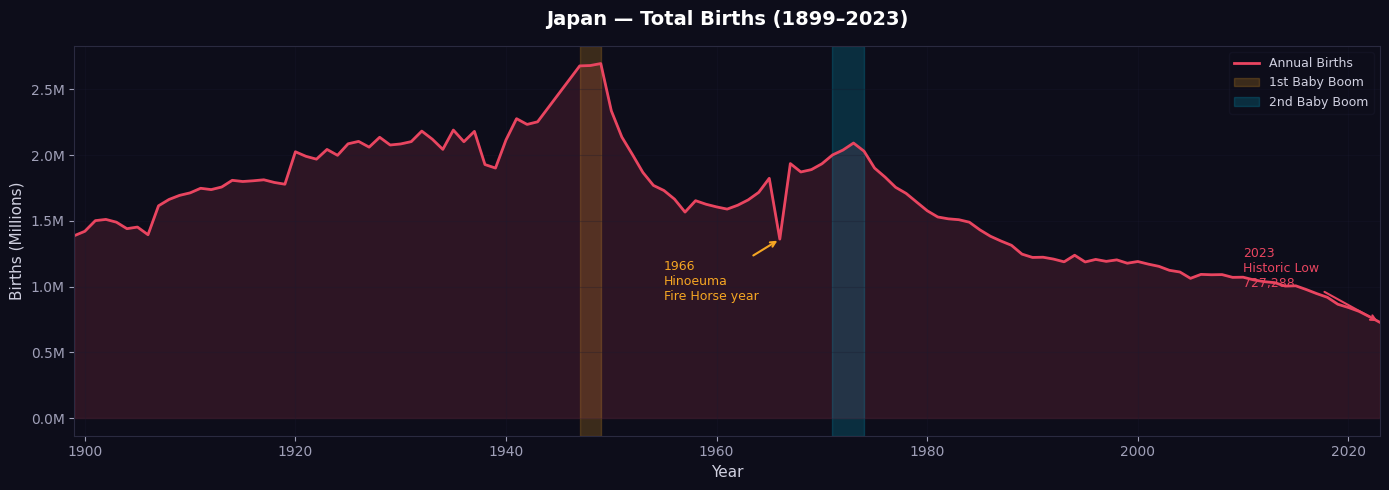

In [ ]:
# Total Births Over Time
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df['year'], df['total_births'] / 1e6,
                alpha=0.15, color=C['red'])
ax.plot(df['year'], df['total_births'] / 1e6,
        color=C['red'], linewidth=2, label='Annual Births')

# Baby boom highlights
ax.axvspan(1947, 1949, alpha=0.2, color=C['gold'],  label='1st Baby Boom')
ax.axvspan(1971, 1974, alpha=0.2, color=C['teal'],  label='2nd Baby Boom')

# 1966 Hinoeuma annotation
ax.annotate('1966\nHinoeuma\nFire Horse year',
                xy=(1966, 1.36),
                xytext=(1955, 0.9),
                arrowprops=dict(arrowstyle='->', color=C['gold'], lw=1.5),
                color=C['gold'], fontsize=9)

# 2023 annotation
ax.annotate('2023\nHistoric Low\n727,288',
                xy=(2023, 0.727),
                xytext=(2010, 1.0),
                arrowprops=dict(arrowstyle='->', color=C['red'], lw=1.5),
                color=C['red'], fontsize=9)

ax.set_title("Japan — Total Births (1899–2023)", fontweight='bold', pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Births (Millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(1899, 2023)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/01_total_births.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

Japan's births peaked at **2.69M in 1949** during the post-war baby boom, 

then declined steadily to a historic low of **727,288 in 2023** — a 73% drop over 74 years.

Baby Boom I (1947–1949)
Following the end of World War II in 1945, soldiers returned home, families reunited, and people once again felt secure and optimistic. A huge increase in births resulted from everyone starting to have children at the same time.

# Rolling Average 

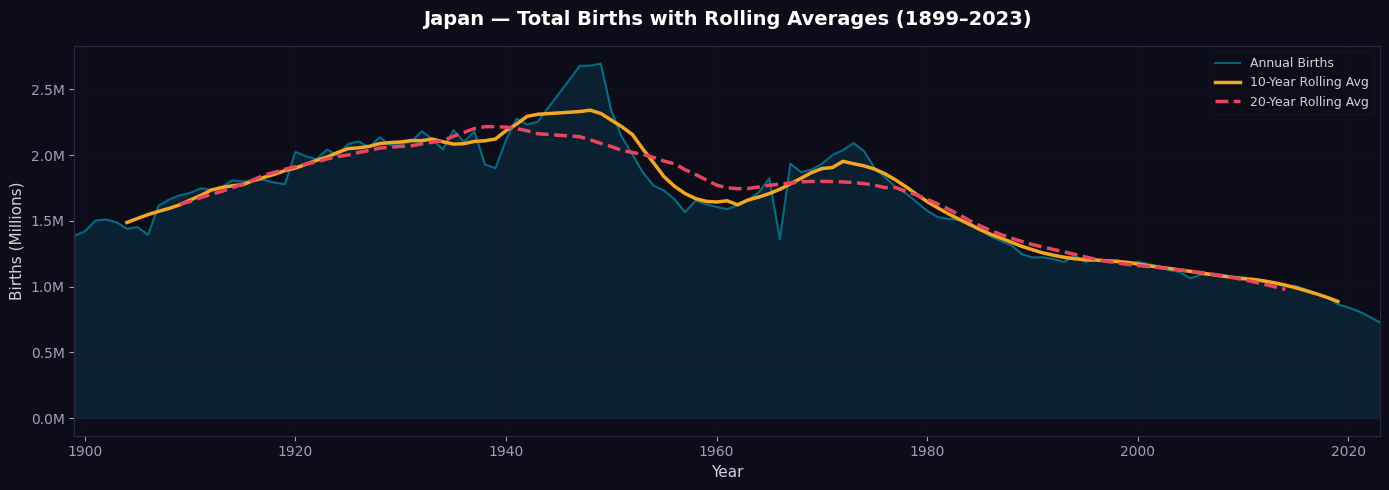

In [ ]:

rolling_10 = df['total_births'].rolling(window=10, center=True).mean()
rolling_20 = df['total_births'].rolling(window=20, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))

# Raw births
ax.fill_between(df['year'], df['total_births'] / 1e6,
                alpha=0.12, color=C['teal'])
ax.plot(df['year'], df['total_births'] / 1e6,
        color=C['teal'], linewidth=1.5, alpha=0.5, label='Annual Births')

# Rolling averages
ax.plot(df['year'], rolling_10 / 1e6,
        color=C['gold'], linewidth=2.5, label='10-Year Rolling Avg')
ax.plot(df['year'], rolling_20 / 1e6,
        color=C['red'], linewidth=2.5, linestyle='--', label='20-Year Rolling Avg')

ax.set_title("Japan — Total Births with Rolling Averages (1899–2023)", fontweight='bold', pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Births (Millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(1899, 2023)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/02_rolling_average.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

 The 10-year rolling average smooths out short-term spikes like 1966, 
 
  revealing a clear structural decline that began in the 1970s and has never reversed.

In [26]:
df.to_csv("../data/backup_japan.csv")

# Male Vs Female Births 

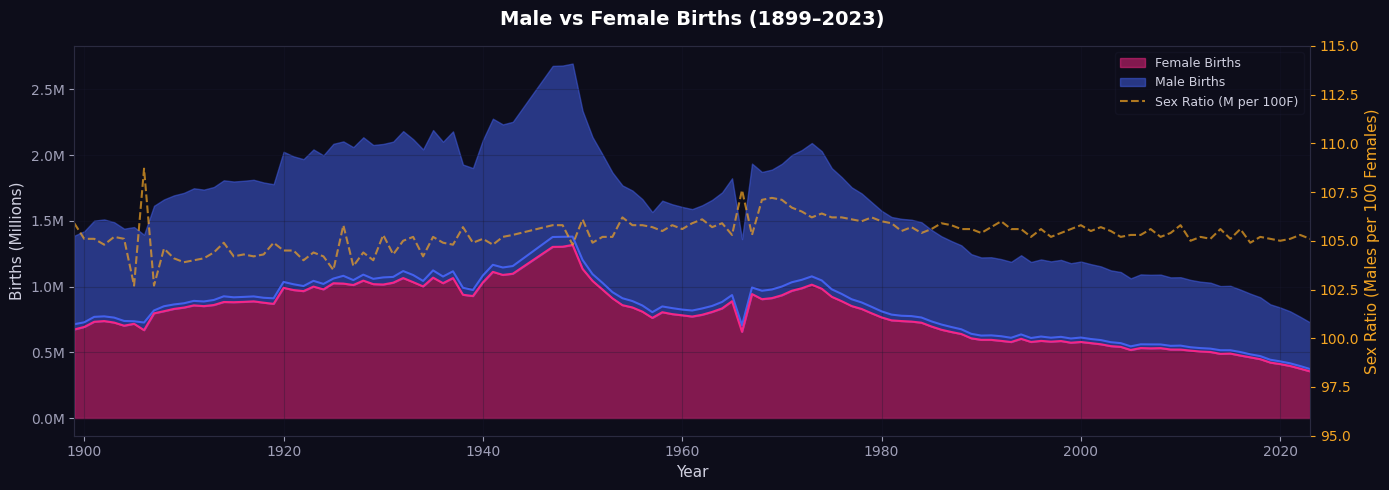

In [ ]:
# Male Vs Female Births over the time periods 
fig, ax = plt.subplots(figsize=(14, 5))

# Stacked area
ax.fill_between(df['year'], df['female_births'] / 1e6,
                alpha=0.5, color=C['pink'], label='Female Births')
ax.fill_between(df['year'], df['female_births'] / 1e6,
                df['total_births'] / 1e6,
                alpha=0.5, color=C['blue'], label='Male Births')

# Lines on top
ax.plot(df['year'], df['male_births'] / 1e6,
        color=C['blue'], linewidth=1.5)
ax.plot(df['year'], df['female_births'] / 1e6,
        color=C['pink'], linewidth=1.5)

# Sex ratio on second axis
ax2 = ax.twinx()
ax2.set_facecolor('#0d0d1a')
ax2.plot(df['year'], df['sex_ratio_at_birth'],
                color=C['gold'], linewidth=1.5, linestyle='--',
                alpha=0.7, label='Sex Ratio (M per 100F)')
ax2.set_ylabel("Sex Ratio (Males per 100 Females)", color=C['gold'])
ax2.tick_params(axis='y', colors=C['gold'])
ax2.set_ylim(95, 115)

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax.set_title("Male vs Female Births (1899–2023)", fontweight='bold', pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Births (Millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(1899, 2023)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/03_male_female_births.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

 Male births consistently outnumber female births across all 124 years. 

 The sex ratio has remained remarkably stable at **~105 males per 100 females**, 

 suggesting no biological shift — only total volume is declining.

In between 1947 and 1940 first baby boom is been seen as after few year it starts to decase and gradully start it increase again in 1971 to 1974 2nd baby boom was seem this period and again from that the baby boom start to decrease due to demographic crisis 

# Crude Birth rate (CBR)

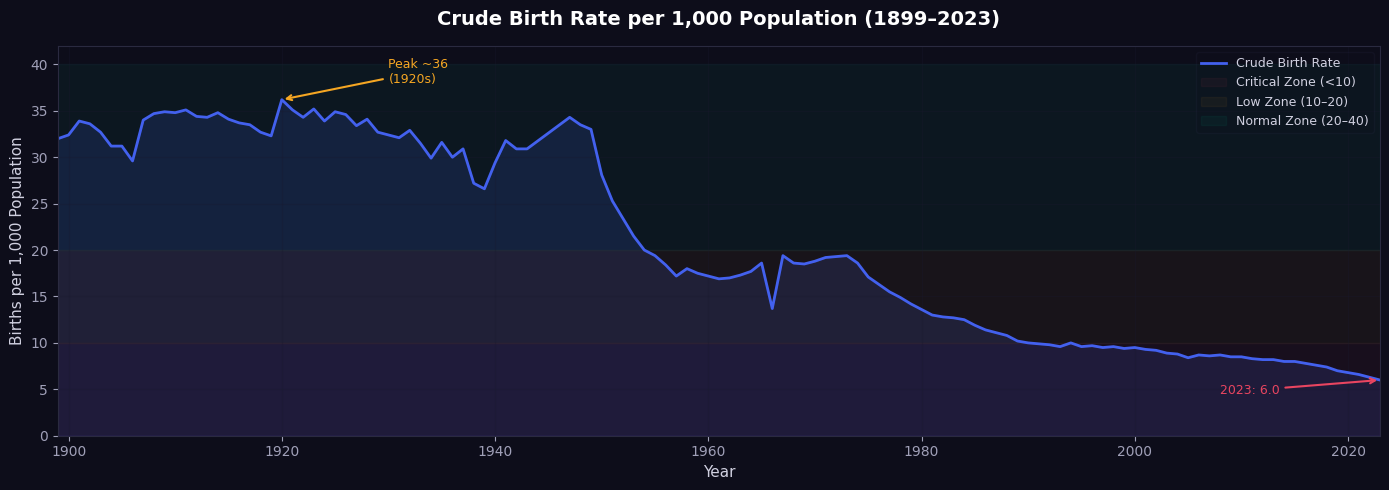

In [ ]:
# Birth rate of Male and Female birth rate 
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df['year'], df['crude_birth_rate'],
                alpha=0.15, color=C['blue'])
ax.plot(df['year'], df['crude_birth_rate'],
        color=C['blue'], linewidth=2, label='Crude Birth Rate')

# Reference zones
ax.axhspan(0,  10, alpha=0.05, color=C['red'],   label='Critical Zone (<10)')
ax.axhspan(10, 20, alpha=0.05, color=C['gold'],  label='Low Zone (10–20)')
ax.axhspan(20, 40, alpha=0.05, color=C['green'], label='Normal Zone (20–40)')

# Annotations
ax.annotate('Peak ~36\n(1920s)',
                xy=(1920, 36.2),
                xytext=(1930, 38),
                arrowprops=dict(arrowstyle='->', color=C['gold'], lw=1.5),
                color=C['gold'], fontsize=9)

ax.annotate(f"2023: {df.loc[df['year']==2023, 'crude_birth_rate'].values[0]}",
                xy=(2023, 6.0),
                xytext=(2008, 4.5),
                arrowprops=dict(arrowstyle='->', color=C['red'], lw=1.5),
                color=C['red'], fontsize=9)

ax.set_title("Crude Birth Rate per 1,000 Population (1899–2023)", fontweight='bold', pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Births per 1,000 Population")
ax.set_xlim(1899, 2023)
ax.set_ylim(0, 42)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_crude_birth_rate.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

Japan's crude birth rate fell from **~36 per 1,000** in the 1920s to just **6.0 in 2023**. 

 Once it crossed below 10 (critical zone), no recovery has been observed.

# Crude Birthrate rate vs Total Fertitlity rate


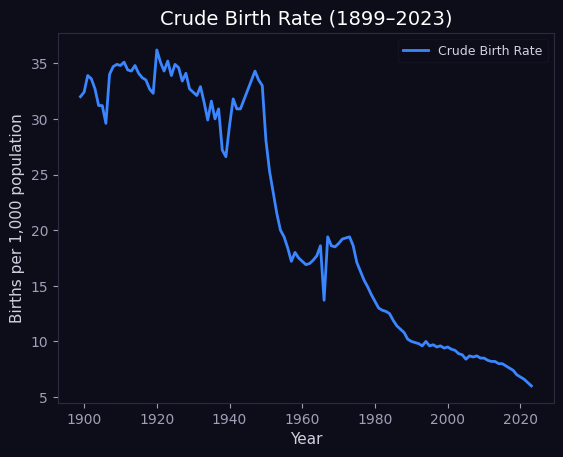

In [55]:
fig, ax = plt.subplots()

ax.plot(df['year'], df['crude_birth_rate'], color='#3a86ff', linewidth=2, label='Crude Birth Rate')

ax.set_title('Crude Birth Rate (1899–2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Births per 1,000 population')
ax.legend()
plt.show()

Between 1899 and 1920 (High & Stable), the CBR was approximately 32–36, which means that 32–36 babies were born annually for every 1,000 people. incredibly high by today's standards.
1920–1940 (Slow Drop)
gradually began to decline as Japan became more urbanized and modernized.
1940–1945 (Sharp Drop)
Families were split up and men were at war during World War II, which led to a sharp decline.
1945–1950 (Spike)
Post-war baby boom: As soldiers returned home, CBR rapidly increased again.
Continuous Decline, 1950–2023: Never recovered. decreased from about 28 to just 6 in 2023.

# Total Fertility Rate

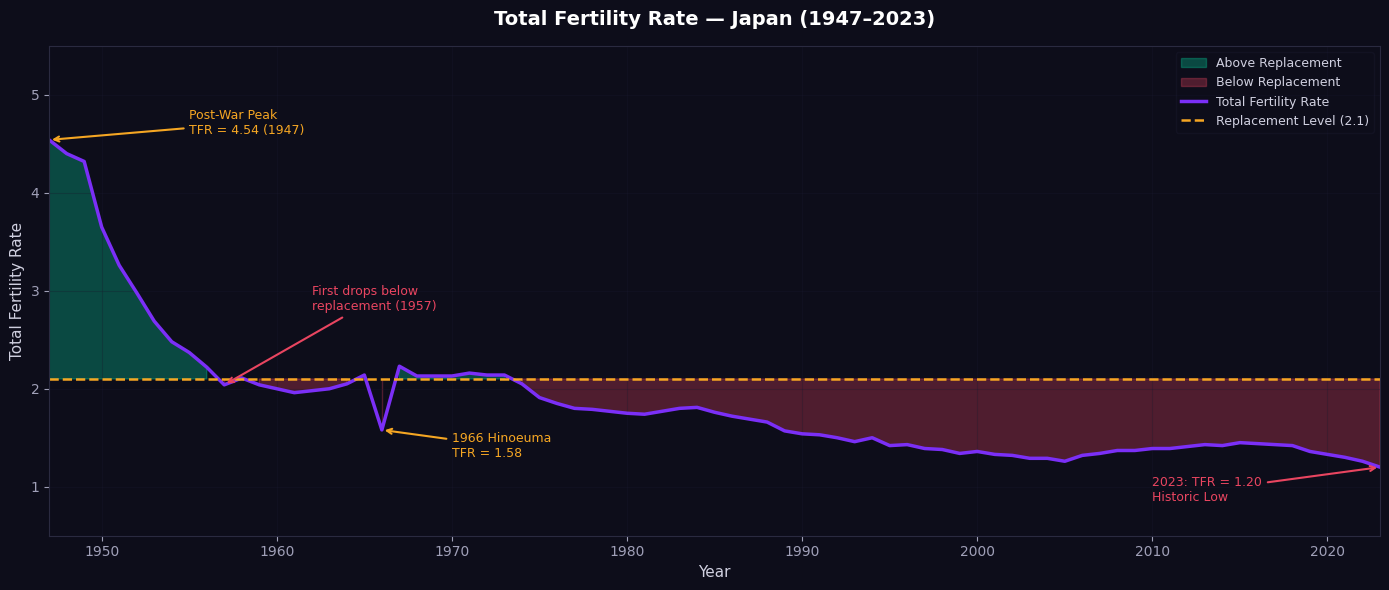

In [ ]:
tfr = df.dropna(subset=['total_fertility_rate'])

fig, ax = plt.subplots(figsize=(14, 6))

# Fill above and below replacement level separately
ax.fill_between(tfr['year'], tfr['total_fertility_rate'], 2.1,
                where=(tfr['total_fertility_rate'] >= 2.1),
                alpha=0.3, color=C['green'], label='Above Replacement')
ax.fill_between(tfr['year'], tfr['total_fertility_rate'], 2.1,
                where=(tfr['total_fertility_rate'] < 2.1),
                alpha=0.3, color=C['red'], label='Below Replacement')

# Main TFR line
ax.plot(tfr['year'], tfr['total_fertility_rate'],
        color=C['purple'], linewidth=2.5, label='Total Fertility Rate')

# Replacement level line
ax.axhline(y=2.1, color=C['gold'], linewidth=1.8,
                linestyle='--', label='Replacement Level (2.1)')

# Annotations
ax.annotate('Post-War Peak\nTFR = 4.54 (1947)',
                xy=(1947, 4.54),
                xytext=(1955, 4.6),
                arrowprops=dict(arrowstyle='->', color=C['gold'], lw=1.5),
                color=C['gold'], fontsize=9)

ax.annotate('First drops below\nreplacement (1957)',
                xy=(1957, 2.04),
                xytext=(1962, 2.8),
                arrowprops=dict(arrowstyle='->', color=C['red'], lw=1.5),
                color=C['red'], fontsize=9)

ax.annotate('1966 Hinoeuma\nTFR = 1.58',
                xy=(1966, 1.58),
                xytext=(1970, 1.3),
                arrowprops=dict(arrowstyle='->', color=C['gold'], lw=1.5),
                color=C['gold'], fontsize=9)

ax.annotate(f'2023: TFR = 1.20\nHistoric Low',
                xy=(2023, 1.20),
                xytext=(2010, 0.85),
                arrowprops=dict(arrowstyle='->', color=C['red'], lw=1.5),
                color=C['red'], fontsize=9)

ax.set_title("Total Fertility Rate — Japan (1947–2023)", fontweight='bold', pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Total Fertility Rate")
ax.set_xlim(tfr['year'].min(), 2023)
ax.set_ylim(0.5, 5.5)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/05_total_fertility_rate.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

 Japan's TFR first dropped below the replacement level of **2.1 in 1957**. 

The 1966 dip to **1.58** was caused by the *Hinoeuma* (Fire Horse) superstition. 

 By 2023 it reached a historic low of **1.20** — nearly half of what's needed to sustain population.

# YoY % Change:

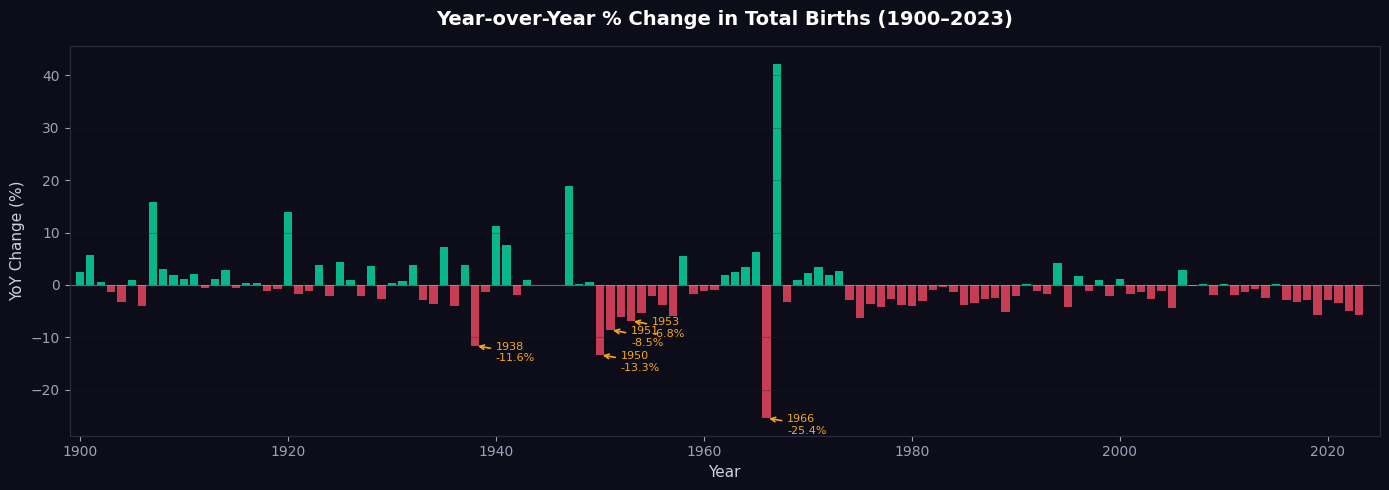

In [50]:
df['yoy_pct_change'] = df['total_births'].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 5))

colors = [C['green'] if x >= 0 else C['red'] for x in df['yoy_pct_change']]

ax.bar(df['year'], df['yoy_pct_change'], color=colors, width=0.8, alpha=0.85)
ax.axhline(y=0, color=C['white'], linewidth=0.8, alpha=0.4)

# Annotate the 5 biggest drops
biggest_drops = df.nsmallest(5, 'yoy_pct_change')[['year', 'yoy_pct_change']]
for _, row in biggest_drops.iterrows():
    ax.annotate(f"{int(row['year'])}\n{row['yoy_pct_change']:.1f}%",
                xy=(row['year'], row['yoy_pct_change']),
                xytext=(row['year'] + 2, row['yoy_pct_change'] - 3),
                arrowprops=dict(arrowstyle='->', color=C['gold'], lw=1.2),
                color=C['gold'], fontsize=8)

# Legend patches
# gain_patch = mpatches.Patch(color=C['green'], label='Births Increased')
# drop_patch = mpatches.Patch(color=C['red'],   label='Births Decreased')
# ax.legend(handles=[gain_patch, drop_patch], loc='lower left')

ax.set_title("Year-over-Year % Change in Total Births (1900–2023)", fontweight='bold', pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("YoY Change (%)")
ax.set_xlim(1899, 2025)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/06_yoy_change.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

 The biggest single-year drop was **1966 (−25%)** due to the Fire Horse superstition. 

Since 2000, almost every bar is red — births have declined **every single year** for over two decades.

green bar above 0 shows births increased compared to previous year whereas red bar shows the births decreased compared to previous year

# Average Births by Era

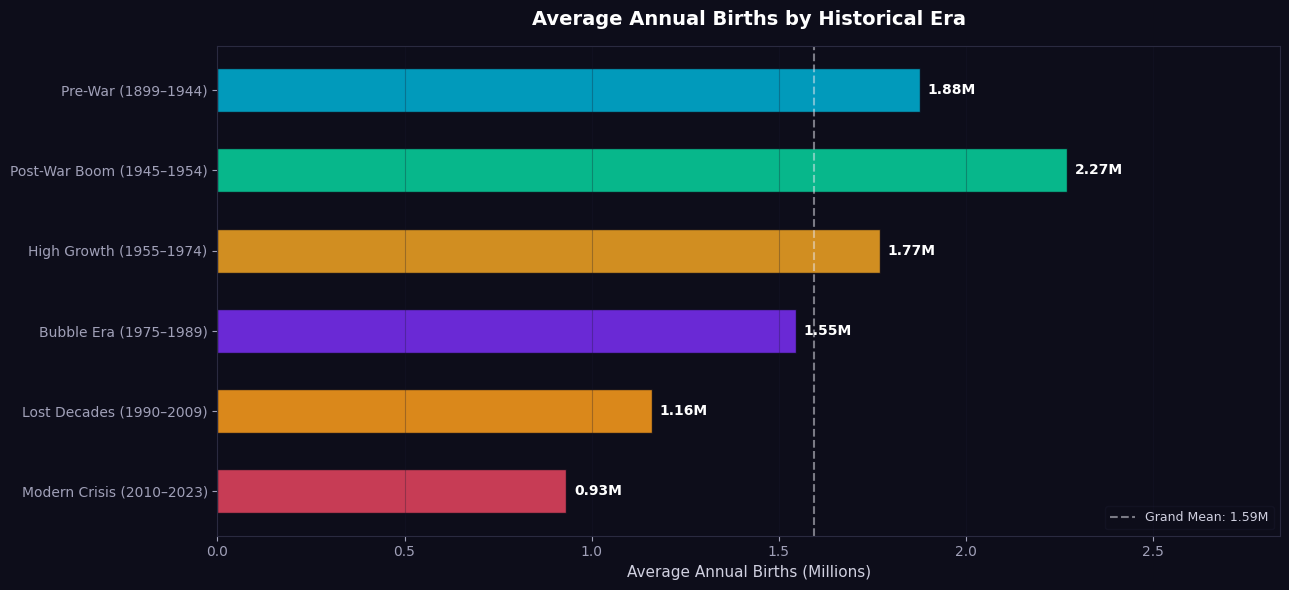

In [ ]:
era_order = [
    'Pre-War (1899–1944)',
    'Post-War Boom (1945–1954)',
    'High Growth (1955–1974)',
    'Bubble Era (1975–1989)',
    'Lost Decades (1990–2009)',
    'Modern Crisis (2010–2023)',
]

era_colours = [C['teal'], C['green'], C['gold'],
                C['purple'], C['orange'], C['red']]

era_stats = df.groupby('era')['total_births'].mean().round(0)
era_stats = era_stats.reindex(era_order) / 1e6

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.barh(era_stats.index, era_stats.values,
                color=era_colours, height=0.55, alpha=0.85,
                edgecolor='#0d0d1a')

# Value labels on each bar
for bar, val in zip(bars, era_stats.values):
    ax.text(val + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}M',
            va='center', fontsize=10,
            color='white', fontweight='bold')

# Grand mean line
ax.axvline(era_stats.mean(), color=C['white'],
            linewidth=1.5, linestyle='--', alpha=0.5,
            label=f'Grand Mean: {era_stats.mean():.2f}M')

ax.set_title("Average Annual Births by Historical Era", fontweight='bold', pad=15)
ax.set_xlabel("Average Annual Births (Millions)")
ax.set_xlim(0, era_stats.max() * 1.25)
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/07_avg_births_by_era.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

The Post-War Boom era had the highest average births at **~2.3M/year**. 

The Modern Crisis era averages just **~933K/year** — less than half the post-war peak, 

 confirming Japan's demographic decline is structural, not temporary.

Biggest bars before and after the war: Japan was at its height of population growth.
Baby Boom: second generation having children, a slight decline from post-war but still very high.
Urbanization, women joining the workforce, and modernization all contributed to the discernible decline.
Japan has just over 1 million average births today, making it the crisis shortest bar. It is evident that there is a demographic crisis. 

# All Chart together 

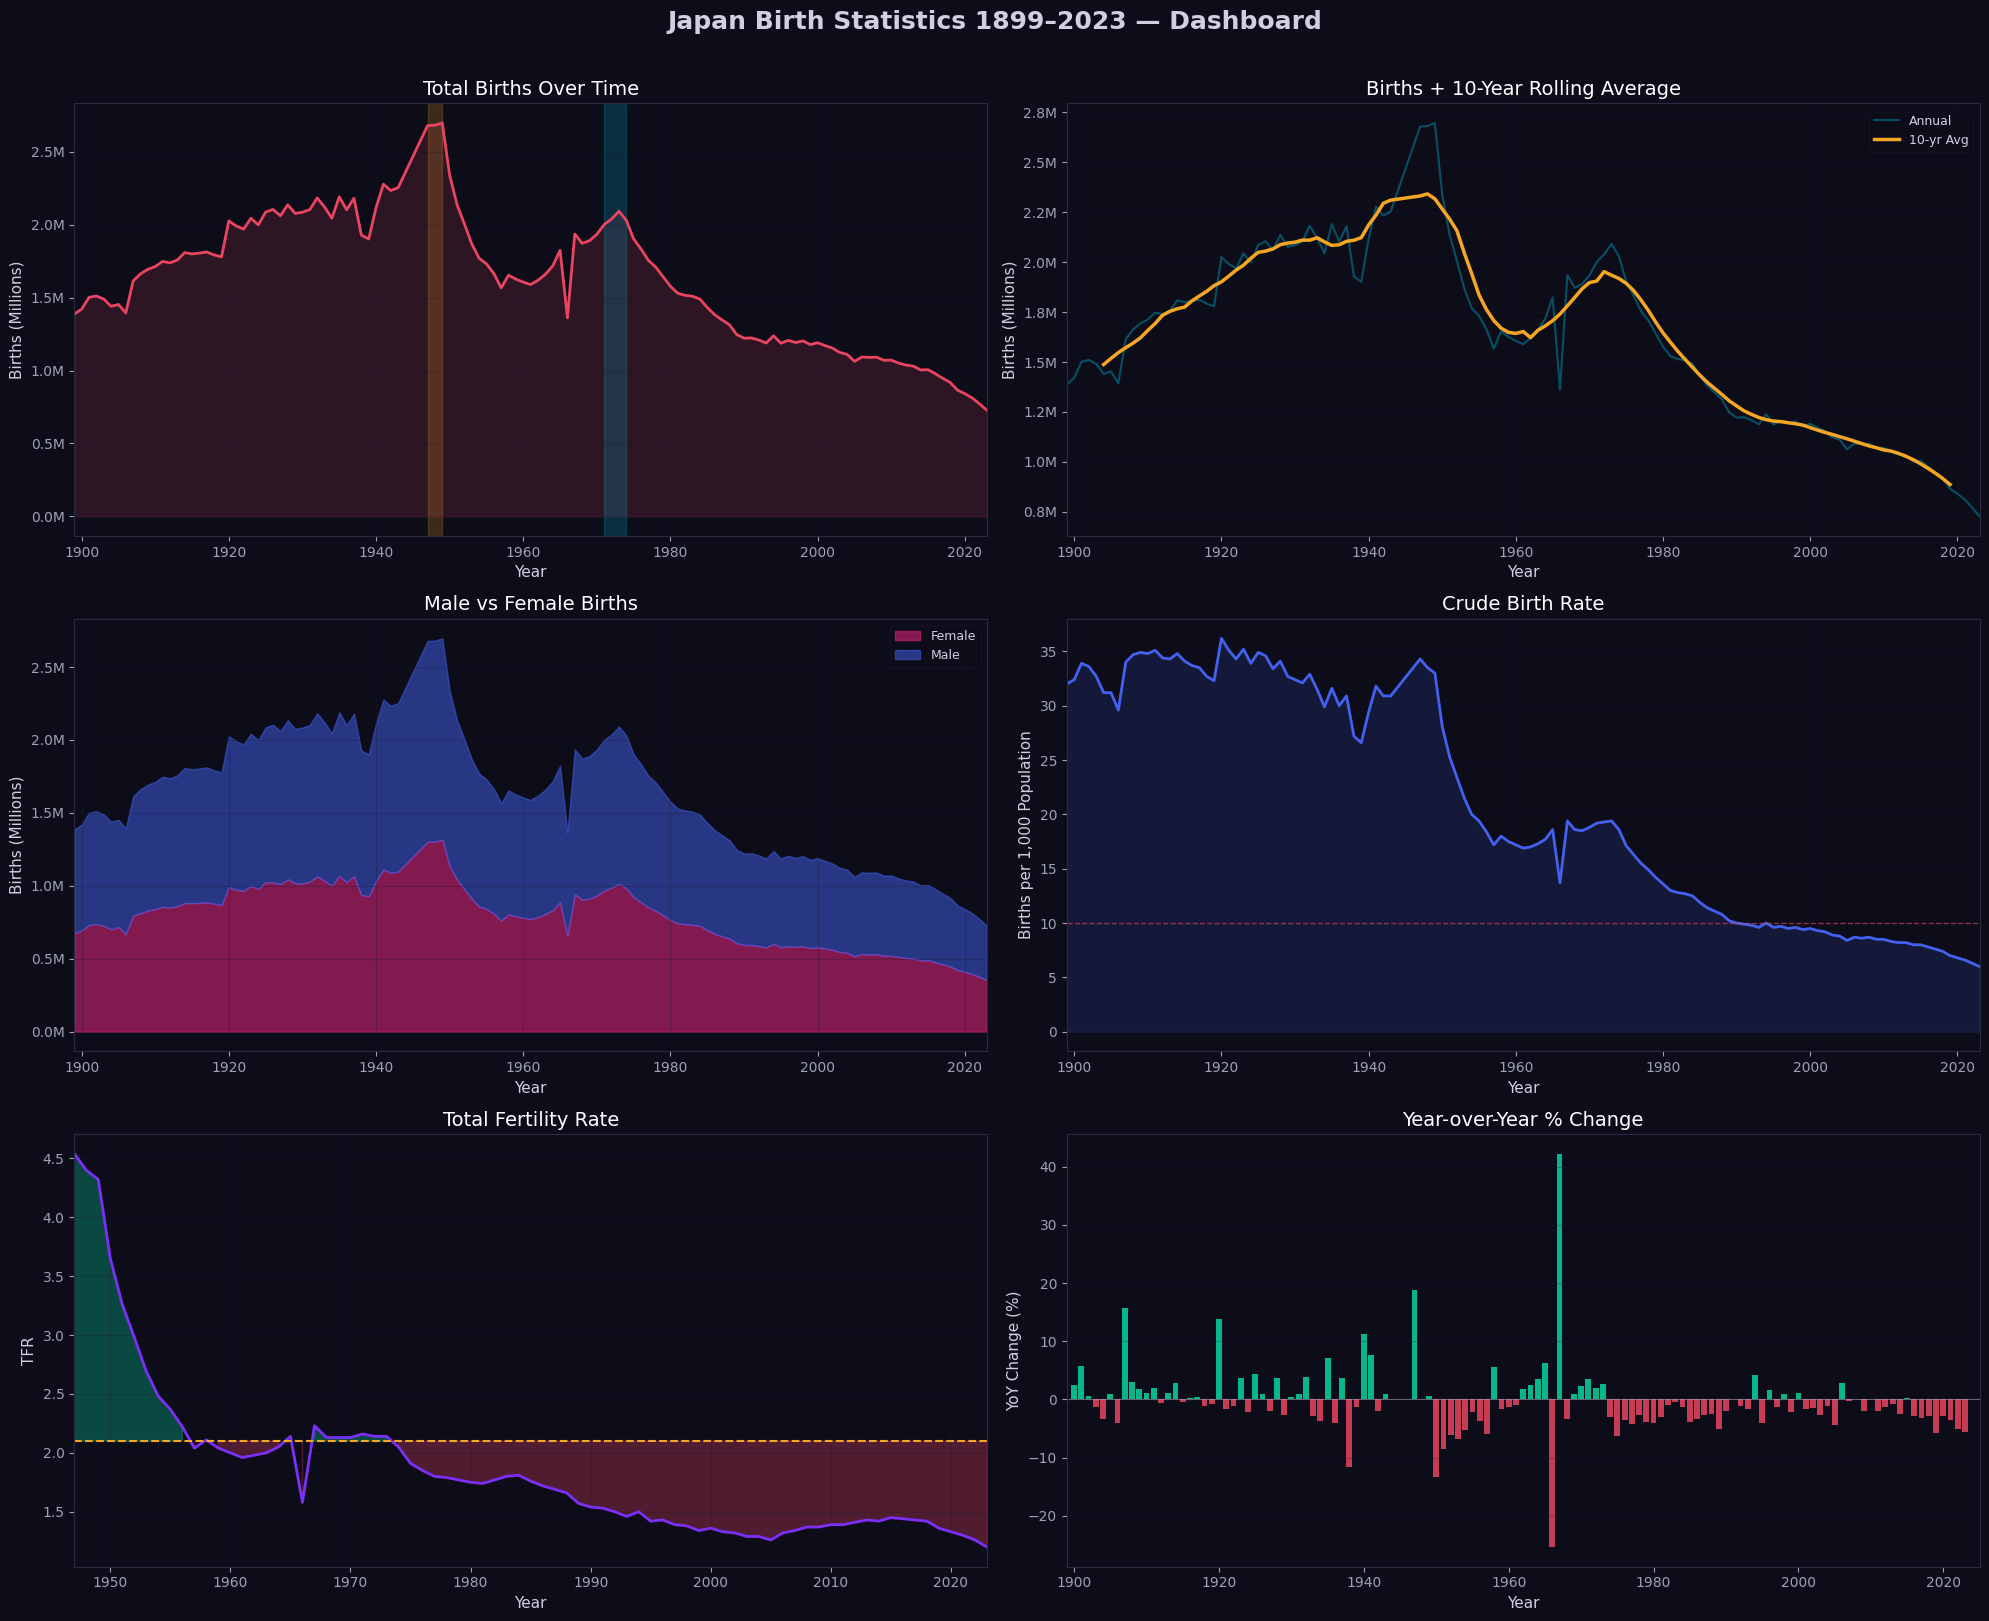

In [ ]:
rolling_10 = df['total_births'].rolling(window=10, center=True).mean()
tfr        = df.dropna(subset=['total_fertility_rate'])

fig, axes = plt.subplots(3, 2, figsize=(20, 16))
fig.suptitle("Japan Birth Statistics 1899–2023 — Dashboard",
                fontsize=18, fontweight='bold', y=1.01)

# ── Chart 1 — Total Births ─────────────────────────────────
ax = axes[0, 0]
ax.fill_between(df['year'], df['total_births'] / 1e6, alpha=0.15, color=C['red'])
ax.plot(df['year'], df['total_births'] / 1e6, color=C['red'], linewidth=2)
ax.axvspan(1947, 1949, alpha=0.2, color=C['gold'])
ax.axvspan(1971, 1974, alpha=0.2, color=C['teal'])
ax.set_title("Total Births Over Time")
ax.set_ylabel("Births (Millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(1899, 2023)
ax.grid(True, alpha=0.3)

# ── Chart 2 — Rolling Average ──────────────────────────────
ax = axes[0, 1]
ax.plot(df['year'], df['total_births'] / 1e6,
        color=C['teal'], linewidth=1.5, alpha=0.4, label='Annual')
ax.plot(df['year'], rolling_10 / 1e6,
        color=C['gold'], linewidth=2.5, label='10-yr Avg')
ax.set_title("Births + 10-Year Rolling Average")
ax.set_ylabel("Births (Millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(1899, 2023)
ax.legend()
ax.grid(True, alpha=0.3)

# ── Chart 3 — Male vs Female ───────────────────────────────
ax = axes[1, 0]
ax.fill_between(df['year'], df['female_births'] / 1e6,
                alpha=0.5, color=C['pink'], label='Female')
ax.fill_between(df['year'], df['female_births'] / 1e6,
                df['total_births'] / 1e6,
                alpha=0.5, color=C['blue'], label='Male')
ax.set_title("Male vs Female Births")
ax.set_ylabel("Births (Millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(1899, 2023)
ax.legend()
ax.grid(True, alpha=0.3)

# ── Chart 4 — Crude Birth Rate ─────────────────────────────
ax = axes[1, 1]
ax.fill_between(df['year'], df['crude_birth_rate'], alpha=0.15, color=C['blue'])
ax.plot(df['year'], df['crude_birth_rate'], color=C['blue'], linewidth=2)
ax.axhline(y=10, color=C['red'], linewidth=1, linestyle='--', alpha=0.6)
ax.set_title("Crude Birth Rate")
ax.set_ylabel("Births per 1,000 Population")
ax.set_xlim(1899, 2023)
ax.grid(True, alpha=0.3)

# ── Chart 5 — TFR ─────────────────────────────────────────
ax = axes[2, 0]
ax.fill_between(tfr['year'], tfr['total_fertility_rate'], 2.1,
                where=(tfr['total_fertility_rate'] >= 2.1),
                alpha=0.3, color=C['green'])
ax.fill_between(tfr['year'], tfr['total_fertility_rate'], 2.1,
                where=(tfr['total_fertility_rate'] < 2.1),
                alpha=0.3, color=C['red'])
ax.plot(tfr['year'], tfr['total_fertility_rate'],
        color=C['purple'], linewidth=2)
ax.axhline(y=2.1, color=C['gold'], linewidth=1.5, linestyle='--')
ax.set_title("Total Fertility Rate")
ax.set_ylabel("TFR")
ax.set_xlim(tfr['year'].min(), 2023)
ax.grid(True, alpha=0.3)

# ── Chart 6 — YoY % Change ────────────────────────────────
ax = axes[2, 1]
colors = [C['green'] if x >= 0 else C['red'] for x in df['yoy_pct_change']]
ax.bar(df['year'], df['yoy_pct_change'], color=colors, width=0.8, alpha=0.85)
ax.axhline(y=0, color=C['white'], linewidth=0.8, alpha=0.4)
ax.set_title("Year-over-Year % Change")
ax.set_ylabel("YoY Change (%)")
ax.set_xlim(1899, 2025)
ax.grid(True, axis='y', alpha=0.3)

for ax in axes.flatten():
    ax.set_xlabel("Year")

plt.tight_layout()
plt.savefig('../reports/08_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

All six indicators tell the same story — Japan's demographic decline is 

consistent, long-term, and accelerating. No single chart is an outlier; 

every metric points toward a deepening population crisis.

##  Conclusion & Key Findings

###  What the Data Tells Us

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Peak Births** | 2,696,638 in 1949 — Post-War Baby Boom |
| 2 | **Historic Low** | 727,288 in 2023 — lowest ever recorded |
| 3 | **Total Decline** | 73% drop from peak to 2023 over 74 years |
| 4 | **Biggest Single Drop** | 1966 − 462,723 births due to Hinoeuma superstition |
| 5 | **TFR Crisis** | First dropped below 2.1 in 1957, never recovered |
| 6 | **2023 TFR** | 1.20 — nearly half the replacement level of 2.1 |
| 7 | **Sex Ratio** | Stable at ~105 males per 100 females across 124 years |
| 8 | **Crude Birth Rate** | Fell from 36 (1920s) to 6.0 (2023) |

---

###  Era Summary

| Era | Avg Annual Births | Story |
|-----|------------------|-------|
| Pre-War (1899–1944) | ~1.88M | Steady growth, industrialisation |
| Post-War Boom (1945–1954) | ~2.32M | Soldiers returned, families reunited |
| High Growth (1955–1974) | ~1.81M | Economic miracle, early fertility decline |
| Bubble Era (1975–1989) | ~1.49M | Urbanisation, women entering workforce |
| Lost Decades (1990–2009) | ~1.17M | Economic stagnation deepens decline |
| Modern Crisis (2010–2023) | ~933K | Accelerating collapse, no recovery in sight |


---

###  3 Critical Insights

**1. It is a structural rather than temporary decline.
All the indicators, including those related to total births, TFR, and crude birth rate, have been decreasing.
more than a hundred days on without a sustained recovery. This is not a short-term dip.

**2. The Hinoeuma effect of 1966 demonstrates that culture determines demographics.
The single superstition had a 25 percent one-year plummet in births. This shows that
demographic data is never merely figures and numbers but they are the mirror of the society, culture and belief.

**3. The crisis is accelerating**
The fall between 1M and 727K was within a period of 13 years (2010- 2023). The pace of
getting worse not better, even with government intervention.

---

###  What Comes Next
We will delve into it in `02 02 statistic analysis.ipynb.
running correlation tests, hypothesis testing and NumPy-powered.
statistical profiling which will help to determine how much strong is this decline.

---
*Japan Birth statistics 1899-2023 Analysis Data Source: Japan Vital Statistics.